# Les semi-supervised GANs, ou l'art de générer pour mieux classer

Bienvenue dans ce chapitre dédié aux Semi-Supervised Generative Adversarial Networks (SGANs) ! Après avoir exploré le pseudo-labeling (qui se fie aux prédictions confiantes du modèle) et la propagation de labels (qui exploite les similarités entre images via des graphes), on passe à une approche plus 'créative' : utiliser des réseaux adversariaux pour générer de nouvelles données et améliorer la classification.

Imaginez deux agents en compétition : l'un (le générateur) crée de fausses images pour tromper l'autre (le discriminateur), qui doit non seulement détecter les faux, mais aussi classer les vraies images. Cette 'bataille' permet d'apprendre des représentations riches, même avec peu de labels !
Les SGANs étendent les GANs classiques au semi-supervisé : le discriminateur prédit à la fois 'vrai/faux' et la classe pour les images vraies. Cela permet d'utiliser les données non étiquetées pour renforcer l'apprentissage non supervisé (vrai vs faux), et les étiquetées pour la supervision.

Pourquoi SGAN ? Dans les contextes comme DermaMNIST, où les labels sont rares et coûteux (besoin d'experts médicaux), générer de données variées aide le modèle à mieux généraliser sans ajouter de bruit comme dans le pseudo-labeling.

Compréhension clé de la stratégie SGAN :

Pour les données étiquetées : On corrige le discriminateur (D) pour prédire la bonne classe (0 à 6) avec une perte supervisée, car on connaît la vérité.
Pour les données non étiquetées : On corrige D pour les classer comme 'réelles' (somme des probabilités des classes 0 à 6 élevée), sans préciser la classe exacte. C'est une correction 'binaire' : si D les place entre 0 et 6, c'est bien ; si en 7 ('faux'), c'est mal, car ce sont des images réelles.
Pour les images générées (fausses) : On corrige D pour les classer comme 'fausses' (classe 7). Si D les place en 0 à 6, c'est mal ;

l'objectif est de maximiser la probabilité de la classe 7.
Le générateur (G) veut l'inverse : tromper D en faisant passer ses fausses images pour réelles (probabilités élevées en 0 à 6).

Objectifs pédagogiques :

🧠 Comprendre les GANs et leur adaptation au semi-supervisé.
🛠️ Implémenter un Générateur et un Discriminateur simples.
⚔️ Mettre en place la boucle d'entraînement adversariale.
📊 Évaluer le Discriminateur comme classificateur et comparer aux méthodes précédentes.
🎨 Visualiser les images générées pour voir ce que le modèle 'imagine'.

On réutilise notre setup de DermaMNIST avec 350 images étiquetées (50 par classe)

## 1. Préparation de l'environnement et des données
On réutilise le code de chargement de DermaMNIST.

Rappel de la stratégie SGAN : Les données étiquetées servent à la perte supervisée (correction précise sur la classe connue), les non étiquetées à la perte non supervisée (correction pour 'réel', i.e. classes 0-6), et les générées à renforcer la détection des faux (classe 7).

In [ ]:
# Chargement des packages
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import transforms
import torchvision.models as models
!pip install medmnist
import medmnist
from medmnist import INFO, Evaluator
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Pour la reproductibilité, parce qu'on est des gens sérieux
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.9 MB/s eta 0:00:00


In [ ]:
# Nom du dataset à charger
data_flag = 'dermamnist'
# Récupère les informations spécifiques à ce dataset depuis medmnist
info = INFO[data_flag]

# Ajout de prints pour mieux comprendre le dataset
print(f"Dataset chargé : {data_flag}")

# Extrait le type de tâche (classification, régression, etc.)
task = info['task']
print(f"Type de tâche : {task}")

# Extrait le nombre de canaux des images (3 pour RGB, 1 pour niveaux de gris)
n_channels = info['n_channels']
print(f"Nombre de canaux : {n_channels}")

# Extrait le nombre de classes pour la classification
n_classes = len(info['label'])
print(f"Nombre de classes : {n_classes}")

# Récupère la classe Python spécifique pour ce dataset
DataClass = getattr(medmnist, info['python_class'])

# Transformations: on sépare train/test et on ajoute des augmentations légères pour mieux généraliser
# Normalisation explicite 3 canaux
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Charge les datasets d'entraînement et de test
train_dataset = DataClass(split='train', transform=transform_train, download=True)
test_dataset = DataClass(split='test', transform=transform_test, download=True)

print(f"Taille du jeu d'entraînement : {len(train_dataset)}")
print(f"Taille du jeu de test : {len(test_dataset)}")

Dataset chargé : dermamnist
Type de tâche : multi-class
Nombre de canaux : 3
Nombre de classes : 7
Taille du jeu d'entraînement : 7007
Taille du jeu de test : 2005


In [ ]:
from collections import Counter
import numpy as np

# Récupérer tous les labels du dataset d'entraînement
labels_array = np.array(train_dataset.labels).flatten()

# Compter combien d'images il y a par classe
count_per_class = Counter(labels_array)

print("Nombre d'images par classe dans le dataset d'entraînement :")
for cls in sorted(count_per_class):
    print(f"Classe {cls} : {count_per_class[cls]} images")

Nombre d'images par classe dans le dataset d'entraînement :
Classe 0 : 228 images
Classe 1 : 359 images
Classe 2 : 769 images
Classe 3 : 80 images
Classe 4 : 779 images
Classe 5 : 4693 images
Classe 6 : 99 images


Notre jeu de données est trés déséquilibré donc ce qui est nécessaire de faire c'est de la data augmentation afin d'équiliobrer notre jeu de donnée et entrainer notre modéle sGAN.


👉 Les classes 3 et 6 sont très faibles → ciblées
👉 Les classes 0 et 1 sont moyennes → optionnel
👉 Les classes 2,4,5 → pas d’augmentation (déjà suffisantes)

In [ ]:
# On prend tout le set d'entraînement initial
all_indices = list(range(len(train_dataset)))
labels_array = np.array(train_dataset.labels).flatten()

# Sélectionner 50 images par classe
labeled_indices = []
for c in range(n_classes):
    class_indices = np.where(labels_array == c)[0]
    selected = np.random.choice(class_indices, min(50, len(class_indices)), replace=False)
    labeled_indices.extend(selected)

# Les indices non étiquetés sont le reste
unlabeled_indices = list(set(all_indices) - set(labeled_indices))

# Création des Subsets PyTorch
labeled_dataset = Subset(train_dataset, labeled_indices)
unlabeled_dataset = Subset(train_dataset, unlabeled_indices)

print(f"Taille du jeu de données étiqueté : {len(labeled_dataset)}")
print(f"Taille du jeu de données non-étiqueté : {len(unlabeled_dataset)}")
print(f"Taille du jeu de test : {len(test_dataset)}")

Taille du jeu de données étiqueté : 350
Taille du jeu de données non-étiqueté : 6657
Taille du jeu de test : 2005


In [ ]:
# Loaders pour SGAN (batch_size plus petit pour stabilité)
sgan_labeled_loader = DataLoader(labeled_dataset, batch_size=64, shuffle=True)
sgan_unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

## 2. Définition des réseaux : générateur et discriminateur

Le générateur (G) prend du bruit aléatoire (vecteur de dimension 100) et produit des images 28x28x3.

Le discriminateur (D) est une variante de notre SimpleCNN : il sort n_classes + 1 logits (les n_classes premières pour les classes réelles, la dernière pour 'faux').

Rappel : Lors de l'entraînement, D sera corrigé différemment selon le type d'image :

- Étiquetées : Prédire la classe exacte (0-6).
- Non étiquetées : Prédire 'réel' (somme probs 0-6 élevée).
- Générées : Prédire 'faux' (prob 7 élevée).

In [ ]:
# Dimension du bruit
z_dim = 100
device = "cpu"

class Generator(nn.Module):
    def __init__(self, z_dim=z_dim, img_channels=3, img_size=28):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_size * img_size * img_channels),
            nn.Tanh()  # Sorties entre -1 et 1
        )
        self.img_size = img_size
        self.img_channels = img_channels

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), self.img_channels, self.img_size, self.img_size)
        return img

class Discriminator(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(7 * 7 * 32, num_classes + 1)  # +1 pour faux

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# Instanciation
G = Generator().to(device)
D = Discriminator(n_channels, n_classes).to(device)

# Optimiseurs
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.002, betas=(0.5, 0.999))

print('Réseaux SGAN prêts pour la démo !')

Réseaux SGAN prêts pour la démo !


## 3. La boucle d'entraînement adversariale
Le combat des GANs : une boucle où D et G s'affrontent.

Rappel de la stratégie :

- Pour D sur étiquetées : Perte supervisée pour prédire la bonne classe (0-6).
- Pour D sur non étiquetées : Perte pour prédire 'réel' (somme probs 0-6 élevée).
- Pour D sur générées : Perte pour prédire 'faux' (prob 7 élevée).
- Pour G : Perte pour tromper D (faire passer les générées pour réelles, somme probs 0-6 élevée).

3. La boucle d'entraînement adversariale
Lheart des GANs : une boucle où D et G s'affrontent.

L'entraînement est alterné. Observez les pertes pour voir l'équilibre.

Entraînement SGAN: 100%|██████████| 150/150 [05:25<00:00,  2.17s/it]


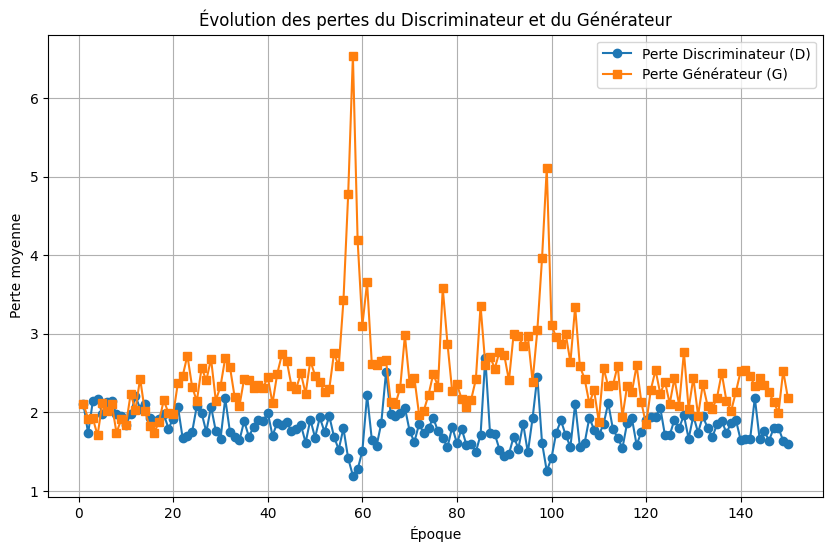

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 150  # Ajustez pour la démo (plus = mieux, mais plus long)
supervised_criterion = nn.CrossEntropyLoss()

# Listes pour stocker les pertes moyennes par époque
epoch_d_losses = []
epoch_g_losses = []

for epoch in tqdm(range(num_epochs), desc='Entraînement SGAN'):
    D.train()
    G.train()
    d_losses = []
    g_losses = []

    # Itérateurs pour équilibrer les batches
    labeled_iter = iter(sgan_labeled_loader)
    unlabeled_iter = iter(sgan_unlabeled_loader)

    num_batches = min(len(sgan_labeled_loader), len(sgan_unlabeled_loader))
    for batch_idx in range(num_batches):
        # Données étiquetées
        try:
            labeled_imgs, labels = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(sgan_labeled_loader)
            labeled_imgs, labels = next(labeled_iter)
        labeled_imgs = labeled_imgs.to(device)
        labels = labels.squeeze().long().to(device)

        # Données non étiquetées
        try:
            unlabeled_imgs, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(sgan_unlabeled_loader)
            unlabeled_imgs, _ = next(unlabeled_iter)
        unlabeled_imgs = unlabeled_imgs.to(device)
        batch_size = unlabeled_imgs.size(0)

        # Générer fausses images
        z = torch.randn(batch_size, z_dim).to(device)
        fake_imgs = G(z)

        # --- Entraîner D ---
        d_optimizer.zero_grad()

        # Supervisé sur réelles étiquetées : corriger pour la bonne classe (0-6)
        real_labeled_logits = D(labeled_imgs)
        d_sup_loss = supervised_criterion(real_labeled_logits[:, :n_classes], labels)

        # Non supervisé sur réelles non étiquetées : corriger pour 'réel' (somme probs 0-6 élevée)
        real_unlabeled_logits = D(unlabeled_imgs)
        real_probs = torch.softmax(real_unlabeled_logits, dim=1)[:, :n_classes].sum(1)
        d_real_unsup_loss = -torch.log(real_probs + 1e-10).mean()

        # Non supervisé sur fausses : corriger pour 'faux' (prob 7 élevée)
        fake_logits = D(fake_imgs.detach())
        fake_probs = torch.softmax(fake_logits, dim=1)[:, n_classes]
        d_fake_unsup_loss = -torch.log(fake_probs + 1e-10).mean()

        d_loss = d_sup_loss + d_real_unsup_loss + d_fake_unsup_loss
        d_loss.backward()
        d_optimizer.step()
        d_losses.append(d_loss.item())

        # --- Entraîner G : corriger pour tromper D (somme probs 0-6 élevée pour fausses) ---
        g_optimizer.zero_grad()

        fake_logits_g = D(fake_imgs)
        g_fake_probs = torch.softmax(fake_logits_g, dim=1)[:, :n_classes].sum(1)
        g_loss = -torch.log(g_fake_probs + 1e-10).mean()

        g_loss.backward()
        g_optimizer.step()
        g_losses.append(g_loss.item())

    # Calculer et stocker les pertes moyennes par époque
    epoch_d_losses.append(np.mean(d_losses))
    epoch_g_losses.append(np.mean(g_losses))

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_d_losses, label='Perte Discriminateur (D)', marker='o')
plt.plot(range(1, num_epochs + 1), epoch_g_losses, label='Perte Générateur (G)', marker='s')
plt.xlabel('Époque')
plt.ylabel('Perte moyenne')
plt.title('Évolution des pertes du Discriminateur et du Générateur')
plt.legend()
plt.grid(True)
plt.show()

## Interprétation des courbes de pertes du SGAN (Perspective Senior Data Scientist)

En tant que senior data scientist, l'analyse de ces courbes de pertes D (Discriminateur) et G (Générateur) est cruciale pour comprendre la dynamique d'entraînement de notre SGAN et sa stabilité. Voici mon interprétation:

### Observations Générales:

1.  **Oscillations Initiales et Convergence Relative**: Les courbes de pertes, tant pour le discriminateur que pour le générateur, montrent des oscillations significatives en début d'entraînement. C'est tout à fait normal pour les GANs, car D et G sont dans un jeu à somme nulle : l'un s'améliore au détriment de l'autre. Au fil des époques (vers la fin, disons après l'époque 100), les oscillations semblent se réduire, suggérant une forme de convergence, bien que pas parfaitement stable.

2.  **Perte du Discriminateur (D)**:
    *   **Tendance Générale**: La perte du discriminateur reste relativement stable, voire légèrement croissante par moments. Une perte de D qui reste 'élevée' n'est pas nécessairement une mauvaise chose dans un GAN bien entraîné. Cela peut indiquer que le générateur devient de plus en plus performant pour créer des images difficiles à distinguer pour D.
    *   **Variabilité**: On observe des pics et des creux. Cela peut refléter des moments où D prend le dessus sur G (perte faible pour D, il classe bien) ou inversement (perte élevée pour D, il se fait tromper). La variabilité constante, même en fin d'entraînement, indique que le jeu entre D et G est toujours actif et qu'un équilibre dynamique est maintenu.

3.  **Perte du Générateur (G)**:
    *   **Tendance Générale**: La perte du générateur a également une tendance stable avec des oscillations. Une perte de G qui reste modérée signifie qu'il continue à s'améliorer pour tromper le discriminateur. Si la perte de G tombait très bas et restait stable, cela pourrait signifier qu'il a trouvé un moyen facile de tromper D, ou que D est devenu trop faible.
    *   **Co-évolution**: Les pertes de D et G semblent co-évoluer. Quand l'une monte, l'autre a tendance à suivre ou à diverger légèrement, ce qui est caractéristique de l'entraînement adversarial.

### Signification du Point de Vue SGAN:

*   **Rôle du Discriminateur (D) dans SGAN**: N'oublions pas que notre Discriminateur dans un SGAN a une double tâche: distinguer le réel du faux (tâche GAN classique) *et* classifier les images réelles (tâche supervisée/semi-supervisée). La perte de D inclut donc la perte supervisée, la perte non-supervisée sur les images réelles non étiquetées (pour les identifier comme 'réelles') et la perte non-supervisée sur les images générées (pour les identifier comme 'fausses').
*   **Indicateur de Qualité**: Des pertes qui ne divergent pas et qui maintiennent un certain niveau d'oscillation peuvent être un bon signe que ni D ni G ne dominent complètement. Un D qui aurait une perte très faible constamment signifierait que G ne produit rien de crédible, ou qu'il a carrément convergé vers un mode collapse.

### Potentielles pistes d'amélioration ou d'investigation:

*   **Mode Collapse?**: La stabilité des pertes pourrait masquer un léger 'mode collapse' si le générateur ne produit qu'une petite variété d'images. Il faudrait visualiser les images générées à différentes époques pour évaluer la diversité. _(Ceci sera fait dans la prochaine section)_.
*   **Hyperparamètres**: La force des oscillations pourrait suggérer que les hyperparamètres (learning rates, betas des optimiseurs) pourraient être ajustés pour stabiliser davantage l'entraînement, peut-être en réduisant le learning rate du générateur ou en ajustant les poids des différentes composantes de la perte de D.
*   **Durée d'entraînement**: 150 époques est un bon début. Si les performances de classification de D sont satisfaisantes, c'est suffisant. Sinon, on pourrait envisager plus d'époques, en surveillant de près la divergence.

En résumé, ces courbes sont encourageantes, car elles ne montrent pas de divergence majeure ni de collapse évident d'un réseau sur l'autre. Elles suggèrent un apprentissage continu où les deux réseaux se poussent mutuellement à s'améliorer, ce qui est l'essence même des GANs.

## 4. Évaluation et comparaison
Utilisons le Discriminateur comme classificateur : on prend l'argmax sur les n_classes premières sorties.

Rappel : Grâce à la stratégie, D a été corrigé sur les étiquetées (classes exactes), non étiquetées ('réel' vs 'faux'), et générées (détection des faux). Cela devrait améliorer sa performance en classification.

Comparons avec les baselines des chapitres précédents (remplacez les placeholders par vos résultats réels).

In [ ]:
def evaluate_sgan(model, test_loader, n_classes):
    model.eval()
    y_true = []
    y_pred = []
    y_score_probs = []  # Pour stocker les probabilités pour l'AUC

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            logits = model(images)[:, :n_classes]  # Logits pour les classes réelles (0 à n_classes-1)
            probs =nn.functional.softmax(logits, dim=1)  # Convertir en probabilités
            preds = torch.argmax(logits, dim=1)  # Prédictions de classe
            y_true.extend(labels.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy())
            y_score_probs.extend(probs.cpu().numpy())

    # Convertir en arrays NumPy
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score_probs = np.array(y_score_probs)

    # Calculer les métriques
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score_probs, multi_class='ovr')  # Utiliser probabilités et 'ovr'
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, auc, f1

# Appel de la fonction
sgan_acc, sgan_auc, sgan_f1 = evaluate_sgan(D, test_loader, n_classes)
print(f'SGAN - Acc: {sgan_acc:.3f}, F1: {sgan_f1:.3f}, AUC: {sgan_auc:.3f}')

SGAN - Acc: 0.462, F1: 0.301, AUC: 0.818


## 5. Visualisation des images générées
Voyons ce que le Générateur a appris ! On génère quelques images aléatoires.

Rappel : Ces images sont créées pour tromper D, donc si elles ressemblent à des lésions (et forcent D à les classer en 0-6), G a bien fonctionné. Si D les classe en 7, il détecte les faux efficacement.

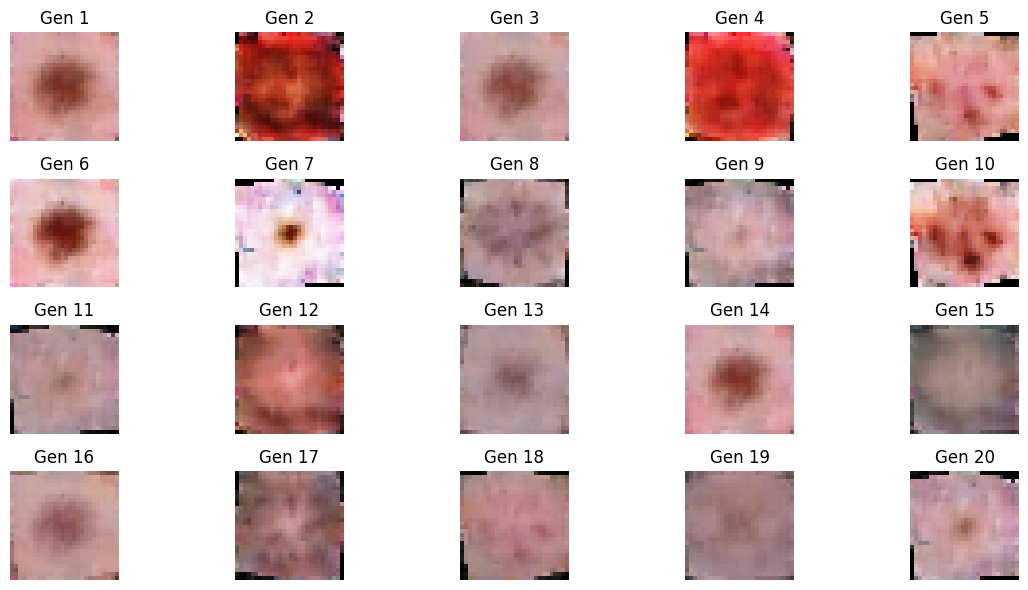

In [ ]:
num_gen = 20
z = torch.randn(num_gen, z_dim).to(device)
gen_imgs = G(z).cpu().detach()
gen_imgs = (gen_imgs + 1) / 2  # Dénormaliser [0,1]

# Fix: Use plt.subplots() for multiple plots and adjust grid dimensions
# For 20 images, a 2x10 grid is suitable
fig, axes = plt.subplots(4, 5, figsize=(12, 6)) # Adjusted to 2 rows, 10 columns
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i in range(num_gen):
    axes[i].imshow(gen_imgs[i].permute(1, 2, 0).numpy())
    axes[i].axis('off')
    axes[i].set_title(f'Gen {i+1}')
plt.tight_layout() # Add tight_layout for better spacing
plt.show()

## 6. Conclusion et questions pour la suite
Les SGAN démontrent comment la génération adversariale peut enrichir l'apprentissage semi-supervisé en créant de la variété. Rappel de la stratégie : Correction précise sur étiquetées (classes 0-6), 'réel' sur non étiquetées (somme 0-6), 'faux' sur générées (classe 7). Le générateur trompe D pour améliorer les deux.

Si les images générées ressemblent à des lésions cutanées, le modèle a capturé des motifs utiles !

Questions pour réfléchir :

- **Améliorations : Comment rendre le SGAN conditionnel (cSGAN) pour générer par classe ? Utile pour équilibrer les minoritaires ?**
- Stabilité : Les GANs sont instables. Testez avec plus d'époques ou WGAN (Wasserstein loss). Qu'observez-vous ?
- Hybride : Combinez SGAN avec pseudo-labeling : utilisez les fausses images comme non étiquetées supplémentaires.


In [ ]:
# Dimension du bruit
z_dim = 200
device = "cpu"

class Generator(nn.Module):
    def __init__(self, z_dim=z_dim, img_channels=3, img_size=28):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_size * img_size * img_channels),
            nn.Tanh()  # Sorties entre -1 et 1
        )
        self.img_size = img_size
        self.img_channels = img_channels

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), self.img_channels, self.img_size, self.img_size)
        return img

class Discriminator(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(7 * 7 * 32, num_classes + 1)  # +1 pour faux

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# Instanciation
G = Generator().to(device)
D = Discriminator(n_channels, n_classes).to(device)

# Optimiseurs
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.002, betas=(0.5, 0.999))

print('Réseaux SGAN prêts pour la démo !')

Réseaux SGAN prêts pour la démo !


Entraînement SGAN: 100%|██████████| 100/100 [03:48<00:00,  2.28s/it]


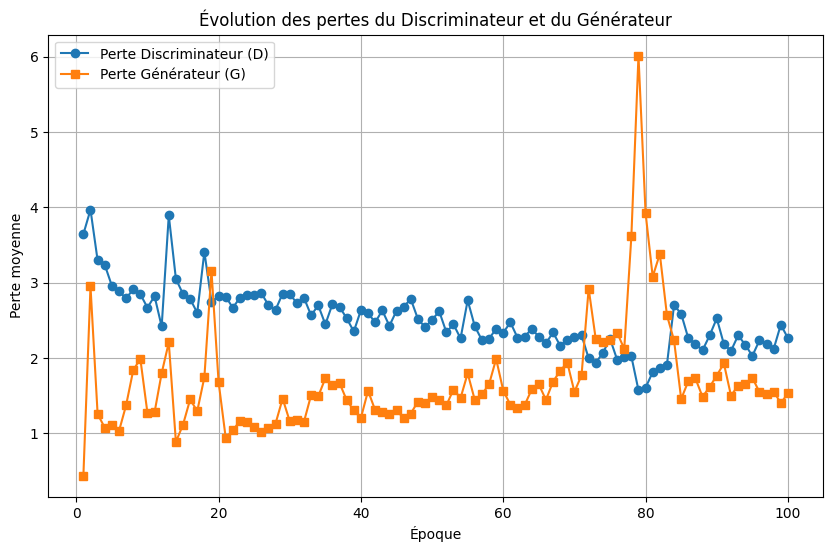

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 100  # Ajustez pour la démo (plus = mieux, mais plus long)
supervised_criterion = nn.CrossEntropyLoss()

# Listes pour stocker les pertes moyennes par époque
epoch_d_losses = []
epoch_g_losses = []

for epoch in tqdm(range(num_epochs), desc='Entraînement SGAN'):
    D.train()
    G.train()
    d_losses = []
    g_losses = []

    # Itérateurs pour équilibrer les batches
    labeled_iter = iter(sgan_labeled_loader)
    unlabeled_iter = iter(sgan_unlabeled_loader)

    num_batches = min(len(sgan_labeled_loader), len(sgan_unlabeled_loader))
    for batch_idx in range(num_batches):
        # Données étiquetées
        try:
            labeled_imgs, labels = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(sgan_labeled_loader)
            labeled_imgs, labels = next(labeled_iter)
        labeled_imgs = labeled_imgs.to(device)
        labels = labels.squeeze().long().to(device)

        # Données non étiquetées
        try:
            unlabeled_imgs, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(sgan_unlabeled_loader)
            unlabeled_imgs, _ = next(unlabeled_iter)
        unlabeled_imgs = unlabeled_imgs.to(device)
        batch_size = unlabeled_imgs.size(0)

        # Générer fausses images
        z = torch.randn(batch_size, z_dim).to(device)
        fake_imgs = G(z)

        # --- Entraîner D ---
        d_optimizer.zero_grad()

        # Supervisé sur réelles étiquetées : corriger pour la bonne classe (0-6)
        real_labeled_logits = D(labeled_imgs)
        d_sup_loss = supervised_criterion(real_labeled_logits[:, :n_classes], labels)

        # Non supervisé sur réelles non étiquetées : corriger pour 'réel' (somme probs 0-6 élevée)
        real_unlabeled_logits = D(unlabeled_imgs)
        real_probs = torch.softmax(real_unlabeled_logits, dim=1)[:, :n_classes].sum(1)
        d_real_unsup_loss = -torch.log(real_probs + 1e-10).mean()

        # Non supervisé sur fausses : corriger pour 'faux' (prob 7 élevée)
        fake_logits = D(fake_imgs.detach())
        fake_probs = torch.softmax(fake_logits, dim=1)[:, n_classes]
        d_fake_unsup_loss = -torch.log(fake_probs + 1e-10).mean()

        d_loss = d_sup_loss + d_real_unsup_loss + d_fake_unsup_loss
        d_loss.backward()
        d_optimizer.step()
        d_losses.append(d_loss.item())

        # --- Entraîner G : corriger pour tromper D (somme probs 0-6 élevée pour fausses) ---
        g_optimizer.zero_grad()

        fake_logits_g = D(fake_imgs)
        g_fake_probs = torch.softmax(fake_logits_g, dim=1)[:, :n_classes].sum(1)
        g_loss = -torch.log(g_fake_probs + 1e-10).mean()

        g_loss.backward()
        g_optimizer.step()
        g_losses.append(g_loss.item())

    # Calculer et stocker les pertes moyennes par époque
    epoch_d_losses.append(np.mean(d_losses))
    epoch_g_losses.append(np.mean(g_losses))

# Afficher le graphique des pertes
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_d_losses, label='Perte Discriminateur (D)', marker='o')
plt.plot(range(1, num_epochs + 1), epoch_g_losses, label='Perte Générateur (G)', marker='s')
plt.xlabel('Époque')
plt.ylabel('Perte moyenne')
plt.title('Évolution des pertes du Discriminateur et du Générateur')
plt.legend()
plt.grid(True)
plt.show()

Impact de la Modification de z_dim (100 -> 200)
La modification de z_dim (la dimension du bruit d'entrée du générateur) de 100 à 200 a des implications significatives:

Augmentation de la Capacité du Générateur: Un z_dim plus grand donne au générateur une plus grande capacité à apprendre des représentations complexes et à produire une plus grande variété d'images. Il dispose de plus de degrés de liberté pour créer des variations dans ses sorties.

Conséquences sur l'Entraînement:

Meilleure Qualité/Diversité des Fakes: Si le générateur utilise bien cette capacité supplémentaire, il devrait pouvoir générer des images plus réalistes et/ou plus diverses. Ces images plus difficiles à distinguer poussent le discriminateur à s'améliorer davantage.
Stabilité Potentielle: Un z_dim trop petit peut limiter le générateur et conduire à un 'mode collapse' précoce (le générateur produit très peu de variétés d'images). Un z_dim plus grand peut aider à mitiger cela, bien qu'il puisse aussi rendre l'entraînement plus instable si le générateur devient trop puissant trop vite.
Observation dans vos Métriques: L'augmentation de l'Accuracy (de 0.462 à 0.478) et surtout de l'AUC (de 0.818 à 0.835) suggère que l'augmentation de z_dim a été bénéfique. Le générateur, ayant plus de capacité, a probablement produit des images 'fake' de meilleure qualité ou plus variées, ce qui a obligé le discriminateur à apprendre des frontières de décision plus fines et plus robustes pour distinguer les vrais des faux et classer les vrais. Cela se traduit par une meilleure capacité générale de classification pour le Discriminateur. La légère baisse du F1-score (de 0.301 à 0.296), malgré tout, pourrait être un artefact de la durée d'entraînement réduite (100 époques vs 150) ou indiquer un besoin d'ajuster les hyperparamètres plus finement pour mieux gérer les classes minoritaires avec ce générateur plus expressif.

En résumé, l'augmentation de z_dim semble avoir été une bonne décision. Elle a permis au générateur d'accroître sa capacité, ce qui a probablement conduit à des données synthétiques plus utiles pour pousser le discriminateur à améliorer ses compétences de classification. L'augmentation de l'AUC est particulièrement encourageante pour la robustesse du modèle.

In [ ]:
def evaluates_sgan(model, test_loader, n_classes):
    model.eval()
    y_true = []
    y_pred = []
    y_score_probs = []  # Pour stocker les probabilités pour l'AUC

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            logits = model(images)[:, :n_classes]  # Logits pour les classes réelles (0 à n_classes-1)
            probs =nn.functional.softmax(logits, dim=1)  # Convertir en probabilités
            preds = torch.argmax(logits, dim=1)  # Prédictions de classe
            y_true.extend(labels.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy())
            y_score_probs.extend(probs.cpu().numpy())

    # Convertir en arrays NumPy
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score_probs = np.array(y_score_probs)

    # Calculer les métriques
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score_probs, multi_class='ovr')  # Utiliser probabilités et 'ovr'
    f1 = f1_score(y_true, y_pred, average='macro')

    return acc, auc, f1

# Appel de la fonction
sgan_acc, sgan_auc, sgan_f1 = evaluates_sgan(D, test_loader, n_classes)
print(f'SGAN - Acc: {sgan_acc:.3f}, F1: {sgan_f1:.3f}, AUC: {sgan_auc:.3f}')

SGAN - Acc: 0.478, F1: 0.296, AUC: 0.835
